In [1]:
import os, random, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from _utils import MMDataset

class DUCMME(nn.Module):
    def __init__(self, embed_dim=200, num_samples=10000, num_views=3, feature_dims=[1000, 1000, 500], hidden_dims=[512, 512, 512], n_clusters=10, alpha=1.0):
        super(DUCMME, self).__init__()
        self.embed_dim = embed_dim; self.num_samples = num_samples; self.num_views = num_views; self.feature_dims = feature_dims; self.hidden_dims = hidden_dims; self.n_clusters = n_clusters; self.alpha = alpha
        # 1. Multi-view Feature Extraction by Fusion-Net
        self.fusion_net_encoder = nn.ModuleList([nn.Sequential(nn.Linear(feature_dims[i], hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(),
                                                               nn.Linear(hidden_dims[i], embed_dim)) for i in range(num_views)]) # encode each view
        self.fusion_net_mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=10, batch_first=True) # batch_first=True: (batch_size, seq_len, hidden_dim)
        self.fusion_net_linear = nn.Linear(3*embed_dim, embed_dim) # linear projection of the fused encoded features
        # 2. Uncertainty-Aware Reconstruction by Reconstruction-Net and Uncertainty-Net
        self.reconstruct_net_list = nn.ModuleList([nn.Sequential(nn.Linear(self.embed_dim, hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(), 
                                                                 nn.Linear(hidden_dims[i], feature_dims[i])) for i in range(num_views)]) # reconstruct each view
        self.uncertainty_net_list = nn.ModuleList([nn.Sequential(nn.Linear(self.embed_dim, hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(), 
                                                                 nn.Linear(hidden_dims[i], feature_dims[i])) for i in range(num_views)]) # predict uncertainty for each view
        # 3. Deep Embedding Clustering by DEC
        self._cluster_centers = nn.Parameter(torch.Tensor(self.n_clusters, self.embed_dim))
        nn.init.xavier_uniform_(self._cluster_centers.data)
        
    def forward_embedding(self, x):
        encoded_output_list = [self.fusion_net_encoder[i](x[i]) for i in range(self.num_views)] # encode each view
        encoded_output_list = torch.stack(encoded_output_list, dim=1) # stack the encoded features from all views, (batch_size, num_views, embed_dim)
        encoded_output_list, _ = self.fusion_net_mha(encoded_output_list, encoded_output_list, encoded_output_list) # fuse the encoded features from all views by a multihead attention, (batch_size, num_views, embed_dim)
        encoded_output_list = encoded_output_list.contiguous().view(encoded_output_list.shape[0], -1) # flatten the encoded features, (batch_size, num_views*embed_dim)
        embedding = self.fusion_net_linear(encoded_output_list) # linear projection of the fused encoded features
        return embedding # get the embedding of the latent space H, (batch_size, embed_dim)

    def forward_uncertainty_aware_reconstruction(self, x):
        embedding = self.forward_embedding(x) # shape: [batch_size, embed_dim]
        reconstructions = [self.reconstruct_net_list[i](embedding) for i in range(self.num_views)] # reconstruct each view
        uncertainties = [self.uncertainty_net_list[i](embedding) for i in range(self.num_views)] # predict uncertainty for each view
        return reconstructions, uncertainties
        
    def forward_similarity_matrix_q(self, x): # calculate the similarity matrix q using t-distribution
        embedding = self.forward_embedding(x) # shape: [batch_size, embed_dim]
        q = 1.0 / (1.0 + torch.sum((embedding.unsqueeze(1) - self._cluster_centers) ** 2, dim=2) / self.alpha) # shape: [batch_size, n_clusters]
        q = q ** ((self.alpha + 1.0) / 2.0) # , shape: [batch_size, n_clusters]
        q = q / torch.sum(q, dim=1, keepdim=True) # Normalize q to sum to 1 across clusters, shape: [batch_size, n_clusters]
        return q, embedding # q can be regarded as the probability of the sample belonging to each cluster
    
    @property
    def cluster_centers(self):
        return self._cluster_centers.data.detach().cpu().numpy() # shape: (n_clusters, embed_dim)
    
    @cluster_centers.setter
    def cluster_centers(self, centers): # shape: (n_clusters, embed_dim)
        centers = torch.tensor(centers, dtype=torch.float32, device=self._cluster_centers.device)
        self._cluster_centers.data.copy_(centers) # copy the cluster centers to the model, set the cluster centers to the new cluster centers
        
    @staticmethod
    def target_distribution(q):
        weight = q ** 2 / torch.sum(q, dim=0) # shape: [batch_size, n_clusters]
        p = weight / torch.sum(weight, dim=1, keepdim=True) # Normalize p to sum to 1 across clusters, shape: [batch_size, n_clusters]
        return p.clone().detach()
    
    def reconstruction_loss(self, x):
        x_rec, _ = self.forward_uncertainty_aware_reconstruction(x) # reconstruct each view and predict uncertainty
        return sum([F.mse_loss(x_rec[v], x[v], reduction='mean') for v in range(self.num_views)]) # sum the losses from all views
    
    def uncertainty_aware_reconstruction_loss(self, x):
        x_rec, log_sigma_2 = self.forward_uncertainty_aware_reconstruction(x) # reconstruct each view and predict uncertainty
        return sum([0.5 * torch.mean((x_rec[v] - x[v])**2 * torch.exp(-log_sigma_2[v]) + log_sigma_2[v]) for v in range(self.num_views)]) # uncertainty is equal to log_sigma_2
    
    def clustering_loss(self, x, p):
        q, _ = self.forward_similarity_matrix_q(x) # shape: [batch_size, n_clusters]
        return F.kl_div(q.log(), p, reduction='batchmean') # shape: ()

In [2]:
random.seed(0); np.random.seed(0); torch.manual_seed(0); torch.cuda.manual_seed_all(0) # Set random seed for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = MMDataset('./data/data_bulk_multiomics/BRCA/', concat_data=False); data = [x.clone().to(device) for x in dataset.X]; label = dataset.Y.clone().numpy()
data_views = dataset.data_views; data_samples = dataset.data_samples; data_features = dataset.data_features; data_categories = dataset.categories
print(data_features)
# Add Column Gaussian Noise
data_add_noise = [x.clone() for x in data]
noise = []; noise_level = []
for i in range(5):
    temp = np.random.normal(0, i, (data_samples, 200))
    temp = np.clip(temp, -i, i)
    noise.append(temp)
    noise_level.append(np.ones((data_samples, 200)) * i)
noise = np.concatenate(noise, axis=1)
noise_level = np.concatenate(noise_level, axis=1)
data_add_noise[0] = data_add_noise[0] + torch.tensor(noise, dtype=torch.float32, device=device)

model = DUCMME(embed_dim=20, feature_dims=data_features, num_views=data_views, hidden_dims=[512, 512, 512], num_samples=data_samples, n_clusters=data_categories, alpha=1.0).to(device)
print("\n=== Stage 1: Uncertainty-Aware Reconstruction Pretraining ===")
print("Basic reconstruction training...")
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    loss = model.reconstruction_loss(data_add_noise)
    loss.backward()
    optimizer.step()
    print(f'Epoch {epoch} completed. Average Loss: {loss.item():.4f}')
print("Uncertainty-aware reconstruction finetuning...")
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    loss = model.uncertainty_aware_reconstruction_loss(data_add_noise)
    loss.backward()
    optimizer.step()
    print(f'Epoch {epoch} completed. Average Loss: {loss.item():.4f}')

modality_mrna shape: (875, 1000)
modality_meth shape: (875, 1000)
modality_mirna shape: (875, 503)
[1000, 1000, 503]

=== Stage 1: Uncertainty-Aware Reconstruction Pretraining ===
Basic reconstruction training...
Epoch 0 completed. Average Loss: 4.3514
Epoch 1 completed. Average Loss: 3.8718
Epoch 2 completed. Average Loss: 3.5565
Epoch 3 completed. Average Loss: 3.3916
Epoch 4 completed. Average Loss: 3.3226
Epoch 5 completed. Average Loss: 3.3054
Epoch 6 completed. Average Loss: 3.3026
Epoch 7 completed. Average Loss: 3.2970
Epoch 8 completed. Average Loss: 3.2837
Epoch 9 completed. Average Loss: 3.2630
Epoch 10 completed. Average Loss: 3.2393
Epoch 11 completed. Average Loss: 3.2153
Epoch 12 completed. Average Loss: 3.1935
Epoch 13 completed. Average Loss: 3.1748
Epoch 14 completed. Average Loss: 3.1589
Epoch 15 completed. Average Loss: 3.1456
Epoch 16 completed. Average Loss: 3.1341
Epoch 17 completed. Average Loss: 3.1237
Epoch 18 completed. Average Loss: 3.1138
Epoch 19 completed

In [3]:
model.eval()
with torch.no_grad():
    reconstructions, uncertainties = model.forward_uncertainty_aware_reconstruction(data_add_noise)

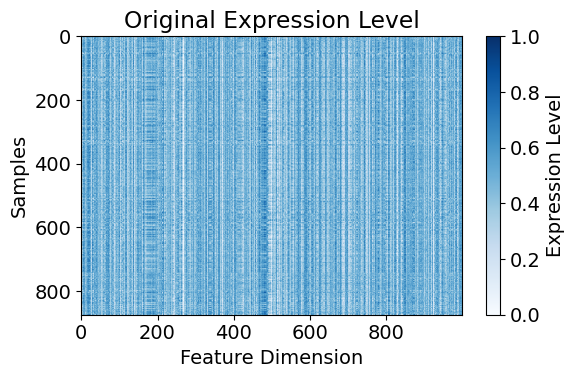

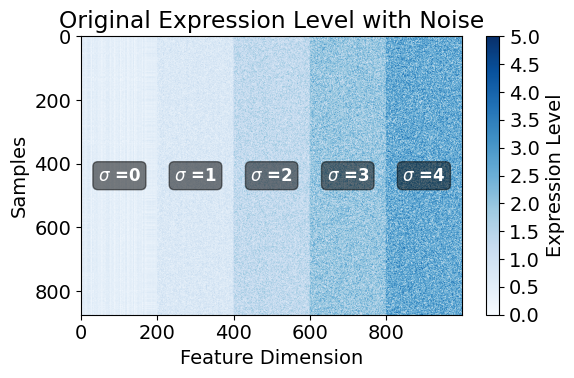

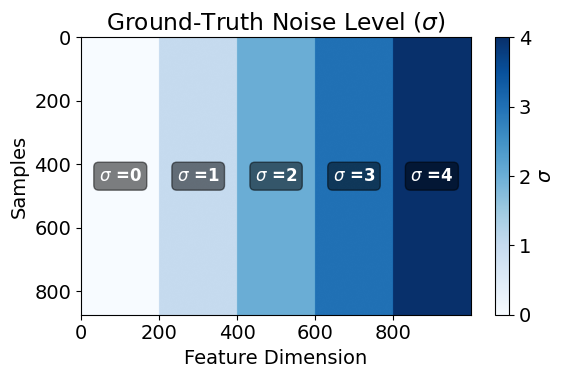

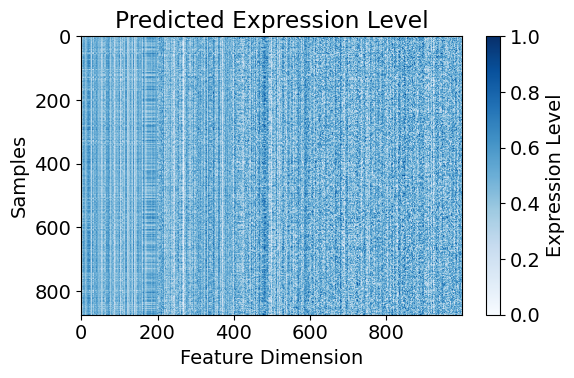

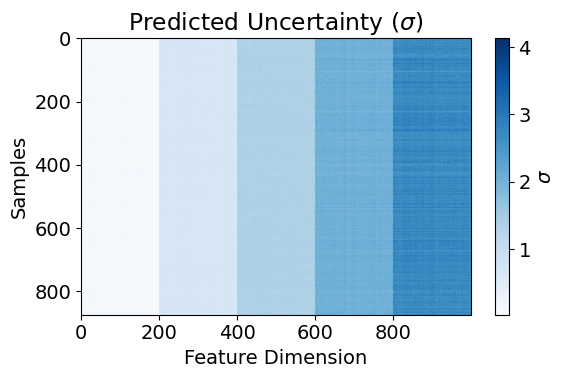

In [4]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14
figure_dir = './figure/hdur_feature_level/BRCA/'
os.makedirs(figure_dir, exist_ok=True)

data_modality_1_original = data[0].cpu().numpy()
data_modality_1_original_noise = data_add_noise[0].cpu().numpy()
data_modality_1_ground_truth_noise = noise_level
data_modality_1_reconstructed = reconstructions[0].cpu().numpy()
data_modality_1_uncertainty = np.exp(0.5 * uncertainties[0].cpu().numpy())

# figure 1: Original Expression Level
fig1, ax1 = plt.subplots(figsize=(6, 4))
im1 = ax1.imshow(data_modality_1_original, aspect='auto', cmap=plt.cm.Blues)
ax1.set_title(r'Original Expression Level', fontweight='normal')
ax1.set_xlabel('Feature Dimension')
ax1.set_ylabel('Samples')
ax1.grid(False)
plt.colorbar(im1, ax=ax1, label=r'Expression Level')
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'stage_1_feature_uncertainty_original_expression_level.png'), dpi=400)
plt.show()

# figure 2: Original Expression Level with Noise
fig1, ax1 = plt.subplots(figsize=(6, 4))
im1 = ax1.imshow(np.abs(data_modality_1_original_noise), aspect='auto', cmap=plt.cm.Blues)
ax1.set_title(r'Original Expression Level with Noise', fontweight='normal')
ax1.set_xlabel('Feature Dimension')
ax1.set_ylabel('Samples')
ax1.grid(False)
# Add sigma labels for each region (each sigma level corresponds to 200 features)
num_samples = data_modality_1_ground_truth_noise.shape[0]
for i, sigma in enumerate([0, 1, 2, 3, 4]):
    x_pos = 100 + i * 200  # Center of each 200-feature region
    y_pos = num_samples / 2  # Middle of the y-axis
    ax1.text(x_pos, y_pos, rf'$\sigma$ ={sigma}', fontsize=12, fontweight='bold', ha='center', va='center', color='white', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
cbar = plt.colorbar(im1, ax=ax1, label=r'Expression Level')
from matplotlib.ticker import MultipleLocator
cbar.ax.yaxis.set_major_locator(MultipleLocator(0.5))
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'stage_1_feature_uncertainty_original_expression_level_with_noise.png'), dpi=400)
plt.show()

# figure 3: Ground-Truth Noise Level
fig1, ax1 = plt.subplots(figsize=(6, 4))
im1 = ax1.imshow(np.abs(data_modality_1_ground_truth_noise), aspect='auto', cmap=plt.cm.Blues)
ax1.set_title(r'Ground-Truth Noise Level ($\sigma$)', fontweight='normal')
ax1.set_xlabel('Feature Dimension')
ax1.set_ylabel('Samples')
ax1.grid(False)
# Add sigma labels for each region (each sigma level corresponds to 200 features)
num_samples = data_modality_1_ground_truth_noise.shape[0]
for i, sigma in enumerate([0, 1, 2, 3, 4]):
    x_pos = 100 + i * 200  # Center of each 200-feature region
    y_pos = num_samples / 2  # Middle of the y-axis
    ax1.text(x_pos, y_pos, rf'$\sigma$ ={sigma}', fontsize=12, fontweight='bold', ha='center', va='center', color='white', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
cbar = plt.colorbar(im1, ax=ax1, label=r'$\sigma$')
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_ticklabels([0, 1, 2, 3, 4])
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'stage_1_feature_uncertainty_ground_truth_noise_level.png'), dpi=400)
plt.show()

# figure 4: Predicted Expression Level
fig1, ax1 = plt.subplots(figsize=(6, 4))
data_modality_1_reconstructed = np.clip(data_modality_1_reconstructed, 0, 1)
im1 = ax1.imshow(data_modality_1_reconstructed, aspect='auto', cmap=plt.cm.Blues)
ax1.set_title(r'Predicted Expression Level', fontweight='normal')
ax1.set_xlabel('Feature Dimension')
ax1.set_ylabel('Samples')
ax1.grid(False)
plt.colorbar(im1, ax=ax1, label=r'Expression Level')
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'stage_1_feature_uncertainty_predicted_expression_level.png'), dpi=400)
plt.show()

# figure 5: Predicted Uncertainty
fig2, ax2 = plt.subplots(figsize=(6, 4))
im2 = ax2.imshow(data_modality_1_uncertainty, aspect='auto', cmap=plt.cm.Blues)
ax2.set_title(r'Predicted Uncertainty ($\sigma$)', fontweight='normal')
ax2.set_xlabel('Feature Dimension')
ax2.set_ylabel('Samples')
ax2.grid(False)
plt.colorbar(im2, ax=ax2, label=r'$\sigma$')
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'stage_1_feature_uncertainty_predicted_uncertainty.png'), dpi=400)
plt.show()


In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr

# 确保使用原始的重构数据（未裁剪的）
data_modality_1_reconstructed_original = reconstructions[0].cpu().numpy()

# 展平数组以便计算指标
original_flat = data_modality_1_original.flatten()
reconstructed_flat = data_modality_1_reconstructed_original.flatten()

# 计算各种评估指标
mse = mean_squared_error(original_flat, reconstructed_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(original_flat, reconstructed_flat)
r2 = r2_score(original_flat, reconstructed_flat)

# 计算相关系数
pearson_corr, pearson_p = pearsonr(original_flat, reconstructed_flat)
spearman_corr, spearman_p = spearmanr(original_flat, reconstructed_flat)

# 打印结果
print("=" * 60)
print("Reconstruction Quality Metrics")
print("=" * 60)
print(f"MSE (Mean Squared Error):        {mse:.6f}")
print(f"RMSE (Root Mean Squared Error):  {rmse:.6f}")
print(f"MAE (Mean Absolute Error):       {mae:.6f}")
print(f"R² (R-squared):                  {r2:.6f}")
print(f"Pearson Correlation:             {pearson_corr:.6f} (p-value: {pearson_p:.2e})")
print(f"Spearman Correlation:            {spearman_corr:.6f} (p-value: {spearman_p:.2e})")
print("=" * 60)

# 也可以按特征维度计算指标（如果需要）
print("\n按特征维度计算的指标:")
print(f"每个特征的平均 MSE: {np.mean((data_modality_1_original - data_modality_1_reconstructed_original) ** 2, axis=0).mean():.6f}")
print(f"每个特征的平均 MAE: {np.mean(np.abs(data_modality_1_original - data_modality_1_reconstructed_original), axis=0).mean():.6f}")


Reconstruction Quality Metrics
MSE (Mean Squared Error):        0.204501
RMSE (Root Mean Squared Error):  0.452218
MAE (Mean Absolute Error):       0.308467
R² (R-squared):                  -3.110724
Pearson Correlation:             0.360890 (p-value: 0.00e+00)
Spearman Correlation:            0.425963 (p-value: 0.00e+00)

按特征维度计算的指标:
每个特征的平均 MSE: 0.204501
每个特征的平均 MAE: 0.308467
